# 02 - Frozen MobileNetV2 (Transfer Learning)

## Project: Malaria Image Classificaiton

This notebook implements a **transfer learning approach** using a pretrained **MobileNetV2** model as a fixed feature extractor for binary classification of blood smear images.

The objective remains:
- **Parasitized** (malaria-infected red blood cell)
- **Uninfected** (healthy red blood cell)

---

## Why Transfer Learning?

Unlike the baseline CNN built from scratch, this approach leverages features learned from the **ImageNet dataset**, allowing:

- Faster convergence
- Improved generalization
- Stronger feature extraction
- Reduced training time

MobileNetV2 is particularly suitable because it is:

- Lightweight and efficient
- Designed for image classification tasks
- Optimized for performance on limited computational resources

---

## Model Strategy: Frozen Base

In this notebook:

- The **MobileNetV2 convolutional base is frozen**
- Pretrained ImageNet weights are preserved
- Only the custom classification head is trained

This allows us to:
- Evaluate how well generic ImageNet features transfer to microscopic blood cell imagery
- Compare performance against the custom baseline CNN

---

## Input Preprocessing

Images are:

- Resized to match MobileNetV2 input requirements
- Preprocessed using 'mobilenet_v2.preprocess_input'
- Normalized according to ImageNet standards

Proper preprocessing is critical for transfer learning performance.

---

## Evaluation Metrics

We evaluate the model using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

---

## Expected Outcome

This model should outperform the baseline CNN due to the strong pretrained feature extractor.

However, because blood smear images differ significantly from natural images, performance limitations may highlight the need for **fine-tuning**, which will be explored in the next notebook.

In [1]:
# Import MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# File and image processing
import os   # Work with file paths
import shutil  # File operations
import cv2  # Image loading and resizing

# TensorFlow / Keras modules for building CNN
from tensorflow.keras.preprocessing.image import ImageDataGenerator                # Image augmentation
from tensorflow.keras.models import Sequential                                     # Model type (sequential layers)
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # Layers for CNN
from tensorflow.keras.callbacks import EarlyStopping                               # Stop training early if overfitting
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Data visualization and analytics
import matplotlib.pyplot as plt # Plot graphs and images
import numpy as np              # Handle arrays and numerical data
import seaborn as sns           # Generate heatmaps and styled plots

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
RAW_DATA_DIR = "data/raw"
BASE_DIR = os.path.join(RAW_DATA_DIR, "cell_images") # Where Kaggle dataset is unzipped
CLEAN_DIR = os.path.join(RAW_DATA_DIR, "clean_cell_images") # Clean folder for training

# Make sure raw folder exists
os.makedirs(RAW_DATA_DIR, exist_ok=True)

# Set Kaggle config directory to current folder
os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()

# Check for kaggle.json (you need to upload it in Colab first)
if not os.path.exists('kaggle.json'):
    raise FileNotFoundError("Kaggle API token file 'kaggle.json' not found. Please upload it to the current directory.")

# Download & unzip dataset **only if it doesn't exist**
if not os.path.exists(BASE_DIR):
    !kaggle datasets download -d 'iarunava/cell-images-for-detecting-malaria' -p {RAW_DATA_DIR} --unzip
else:
    print("Dataset already downloaded and unzipped.")

# Detect whether there is a nested cell_images folder
if os.path.exists(os.path.join(BASE_DIR, "cell_images")):
  # Nested case: cell_images/cell_images/Parasitized
  DATA_SOURCE_DIR = os.path.join(BASE_DIR, "cell_images")
else:
  # Normal case: cell_images/Parasitized
  DATA_SOURCE_DIR = BASE_DIR

print("Using data source dictionary:", DATA_SOURCE_DIR)

# Remove old clean folder if it exists
if os.path.exists(CLEAN_DIR):
  shutil.rmtree(CLEAN_DIR)

# Copy clean structure
shutil.copytree(
    os.path.join(DATA_SOURCE_DIR, "Parasitized"),
    os.path.join(CLEAN_DIR, "Parasitized")
)

shutil.copytree(
    os.path.join(DATA_SOURCE_DIR, "Uninfected"),
    os.path.join(CLEAN_DIR, "Uninfected")
)

print("Clean dataset ready at:", CLEAN_DIR)

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
 98% 659M/675M [00:00<00:00, 1.71GB/s]
100% 675M/675M [00:00<00:00, 1.71GB/s]
Using data source dictionary: data/raw/cell_images/cell_images
Clean dataset ready at: data/raw/clean_cell_images


Number of Parasitized images: 13780
Number of Uninfected images: 13780


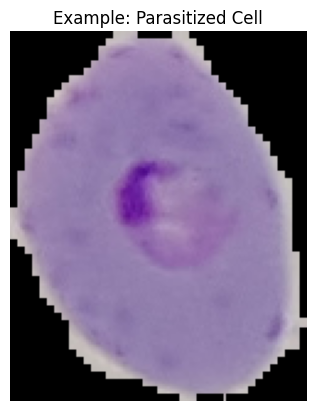

In [4]:
# List all images in each category
parasitized = os.listdir('data/raw/cell_images/Parasitized')
uninfected = os.listdir('data/raw/cell_images/Uninfected')

print(f"Number of Parasitized images: {len(parasitized)}")
print(f"Number of Uninfected images: {len(uninfected)}")

# Display an example image from the Parasitized class
img_path = 'data/raw/cell_images/Parasitized/' + parasitized[0]
img = cv2.imread(img_path)

# Convert from BGR (OpenCV default) to RGB for correct plotting
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# SDhow the image
plt.imshow(img_rgb)
plt.title("Example: Parasitized Cell")
plt.axis('off')
plt.show()

In [5]:
DATA_SET_PATH = 'data/raw/clean_cell_images'
# Training data generator
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,        # Randomly rotate images by up to 20 degrees
    width_shift_range=0.1,    # Shift images horizontally by up to 10%
    height_shift_range=0.1,   # Shift images vertically by up to 10%
    shear_range=0.2,          # Shear transformations
    zoom_range=0.1,           # Zoom in/out randomly
    horizontal_flip=True,     # Flip images horizontally
    fill_mode='nearest',      # Fill in new pixels after transformations
    validation_split=0.2      # Reserve 20% of data for validation
)

# Validation Data Generator
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# Create Training Dataset Generator
train = train_datagen.flow_from_directory(
    CLEAN_DIR, # Path to dataset
    target_size=(128,128),                    # Resize all images to 128x128 pixels
    batch_size=32,                            # Number of images per batch
    class_mode='binary',                      # Binary classification: Parasitized vs Uninfected
    subset='training',                        # Uses 80% of images for training
    shuffle=True                              # Shuffle images each epoch
)

# Create Validation Dataset Generator
val = val_datagen.flow_from_directory(
    CLEAN_DIR,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation',                      # Uses 20% of images for validation
    shuffle=False                             # No need to shuffle for validation
    )

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [6]:
# Build the MobileNetV2 Model
# Load pretrained MobileNetV2 without the top classifier
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False, # Remove ImageNet classifier
    weights="imagenet"
)

# Freeze the base model so we don't destroy pretrained features
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

# Compile
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# Train MobileNetV2
early_stop_mobilenet = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_mobilenet = mobilenet_model.fit(
    train,
    validation_data=val,
    epochs=15,
    callbacks=[early_stop_mobilenet]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 142s 172ms/step - accuracy: 0.8623 - loss: 0.3261 - val_accuracy: 0.8717 - val_loss: 0.3249
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9101 - loss: 0.2331 - val_accuracy: 0.9002 - val_loss: 0.2607
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9136 - loss: 0.2202 - val_accuracy: 0.9103 - val_loss: 0.2304
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9177 - loss: 0.2079 - val_accuracy: 0.9102 - val_loss: 0.2259
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9227 - loss: 0.2057 - val_accuracy: 0.9053 - val_loss: 0.2366
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9235 - loss: 0.2047 - val_accuracy: 0.9165 - val_loss: 0.2131
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9282 - loss: 0.1974 - val_accuracy: 0.9058 - val_loss: 0.2320
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9252 -

173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8871 - loss: 0.2716
Validation Accuracy: 0.9165
Validation Loss: 0.2131


173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step


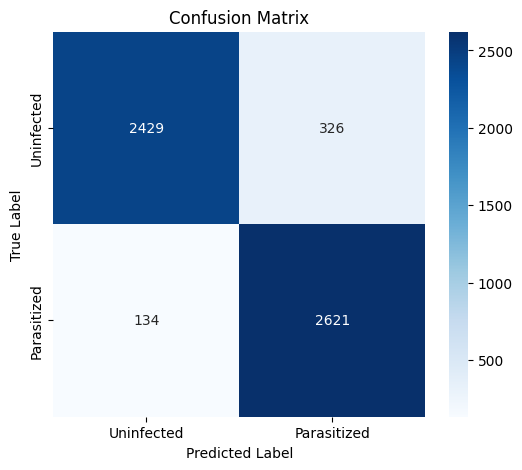

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.95      0.88      0.91      2755
 Parasitized       0.89      0.95      0.92      2755

    accuracy                           0.92      5510
   macro avg       0.92      0.92      0.92      5510
weighted avg       0.92      0.92      0.92      5510



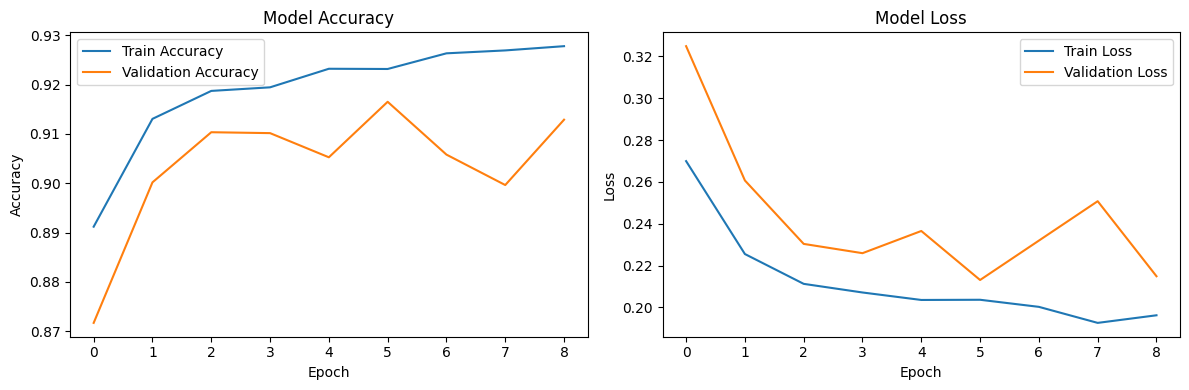

In [10]:
# Evaluate Model on Validation Data
val_loss, val_acc = mobilenet_model.evaluate(val)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print("\n")

# Predict on Validation Data
# model.predict returns probabilities (0 to 1)
y_pred_probs = mobilenet_model.predict(val, steps=len(val))
y_pred = (y_pred_probs > 0.5).astype("int32").ravel() # Convert probabilities to 0 or 1

# True labels from the validation generator
y_true = val.classes

# Confusion Matrix
cm_frozen = confusion_matrix(y_true, y_pred)

# Plot it
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_custom, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Uninfected','Parasitized'],
    yticklabels=['Uninfected','Parasitized']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Uninfected','Parasitized']))

# Plot Training History
plt.figure(figsize=(12,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
from google.colab import files

# Save the MobileNetV2 Model
mobilenet_model.save("malaria_mobilenetv2_frozen.keras")
print("Saved MobileNetV2 model.")

# Download the saved model to your local machine
files.download('malaria_mobilenetv2_frozen.keras')

# Save the model's weights
mobilenet_model.save_weights("malaria_mobilenetv2_frozen_weights_only.weights.h5")
print("Saved MobileNetV2 model's weights.")

# Download the saved model weights to your local machine
files.download('malaria_mobilenetv2_frozen_weights_only.weights.h5')

# Save confusion matrix
np.save("mobilenetv2_frozen_cm.npy", cm_frozen)

Saved MobileNetV2 model.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved MobileNetV2 model's weights.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>